## Find interesting results in MPRAlm results
- significant positive negative numbers
- proportion of AF (variant_type) in significant positive and negative numbers
- proportion of cell-type variant (cardiac, neuro, cava or random) in significant positive and negative numbers
- proportion of enformer group in positive and negative numbers (high effect (significant), low effect (not-significant), random: more negative effects than positive effects?)

In [2]:
import pandas as pd 
import yaml 
import matplotlib.pyplot as plt

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/config/config.yaml"
# load config file
with open(config_path, "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

bcMPRAlm_table = pd.read_feather(config["files"]["toptable_standard"]) 
# bcMPRAlm_table = pd.read_feather(config["files"]["toptable_lowConfig"]) 
print("%s analyzable variants"%(bcMPRAlm_table.shape[0])) # 41284 rows; low config: 42137 rows

# remove lable from variant ID
bcMPRAlm_table["ID"] = bcMPRAlm_table["variant_id"].str.split(":").str[1]


41284 analyzable variants


In [3]:
# investigate the ID column
# check number of pipes in ID column
sum(bcMPRAlm_table.ID.str.count(r'\|') == 3)
# bcMPRAlm_table.shape[0]
# => some have not the same pipe number => check pipe number distribution

41043

In [4]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID
0,1.457470,1.860273,16.934362,1.391612e-54,5.745132e-50,112.182220,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...
1,1.606096,0.968831,12.628304,7.841742e-32,1.618692e-27,60.226634,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...
2,1.530731,0.922960,12.211137,3.236622e-30,4.454024e-26,56.690094,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...
3,0.854324,0.986099,10.631182,6.761656e-25,6.978705e-21,45.648003,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...
4,-1.408756,0.848891,-10.657034,6.293910e-24,5.196756e-20,42.785311,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...
...,...,...,...,...,...,...,...,...
41279,0.002428,0.002055,0.030842,9.754030e-01,9.963546e-01,-6.739143,cardiac_neuro_cava_random:NBEA|ENSG00000172915...,NBEA|ENSG00000172915.20|EH38E3060486|13-353068...
41280,-0.002199,0.119083,-0.028398,9.773511e-01,9.963742e-01,-6.739197,cardiac_neuro_cava_random:SMAD3|ENSG0000016694...,SMAD3|ENSG00000166949.17|EH38E3141548|15-67111...
41281,0.001092,0.050010,0.013630,9.891285e-01,9.977927e-01,-6.739219,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...
41282,-0.000766,0.127814,-0.009803,9.921811e-01,9.987905e-01,-6.739465,cardiac_neuro_cava_random:LINC01626|ENSG000002...,LINC01626|ENSG00000223765.3|EH38E2478380|6-714...


### Vulcano plot

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# create new column with negative log10 p-value
bcMPRAlm_table["nlog10"] = -np.log10(bcMPRAlm_table["adj.P.Val"])

In [9]:
# add class to plot for colors
def map_color_precise(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        if abs(log2fc) >= log2fc_threshold:
            return "interesting_high_log2fc"
        else:
            return "interesting_low_pvalue"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        if abs(log2fc) < log2fc_threshold: 
            return "uninteresting_low_log2fc"
        else: 
            return "uninteresting_high_pvalue" 
    return "possibly_interesting"

def map_color(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        return "interesting"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        return "uninteresting" 
    return "possibly_interesting"

In [10]:
bcMPRAlm_table['color'] = bcMPRAlm_table[['logFC', 'variant_id', 'nlog10']].apply(map_color_precise, axis=1)
bcMPRAlm_table['color'].value_counts()

# more precise split (interesting: abs(log2fc) >= 1 and nlog10 >= 2
# uninteresting_low_log2fc    40930
# interesting_low_pvalue        191
# interesting_high_log2fc       163

# normal split (interesting: abs(log2fc) >= 1 or nlog10 >= 2)
# color
# uninteresting    40930
# interesting        354

# interesting: abs(log2fc) >= 0.5 or nlog10 >= 2
# color
# uninteresting_low_log2fc    39428
# interesting_high_log2fc      1816
# interesting_low_pvalue         40

# => interesing 1856 variants

# 
# http://localhost:8888/tree?token=2c5277b673e1069ca905260d17529bb763643def53e8ed56 228

color
uninteresting_low_log2fc    40930
interesting_low_pvalue        191
interesting_high_log2fc       163
Name: count, dtype: int64

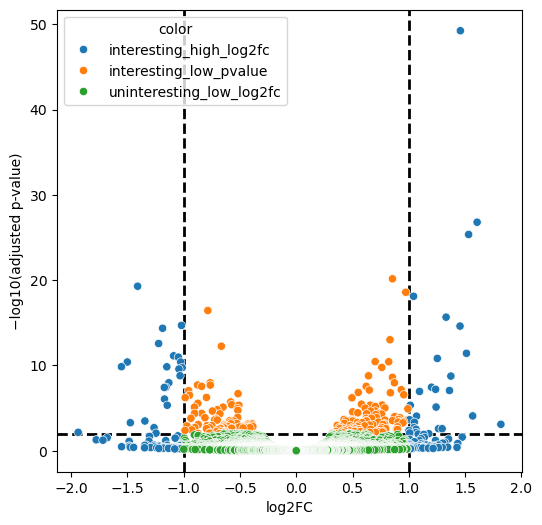

In [11]:
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(data=bcMPRAlm_table, x="logFC", y="nlog10", hue="color")
# y-axis label: -log10(adjusted_p-value)
ax.set(xlabel="log2FC", ylabel="−log10(adjusted p-value)")


ax.axhline(2, zorder = 0, c='k', lw=2, ls = '--')
ax.axvline(1, zorder = 0, c='k', lw=2, ls = '--')
ax.axvline(-1, zorder = 0, c='k', lw=2, ls = '--')

Looking into the results of the experiment:
- standard vs lowConfig: 
- correlation of DNA and RNA counts per replicate: (problem with plotting in MPRAsnakeflow)
   - DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_DNA_pairwise_minThreshold.png`
   - Ratio: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_Ratio_pairwise_minThreshold.png`
   - RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_RNA_pairwise_minThreshold.png`
- barcode: assigned counts vs all counts: correlation among replicates and count per insert distribution 
   - assigned counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - assigned counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count: DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_DNA_perBarcode.png`
   - count: RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_RNA_perBarcode.png`
   - all counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - all counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count distri DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_RNA_perBarcode.png`
   - count distri RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_DNA_perBarcode.png`


- correlation_lowconfig: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_lowConfig_barcode_RNA_pairwise.png`
   - Check up with Martin (check the exact numbers (how many are significant, how many are over log2FC))

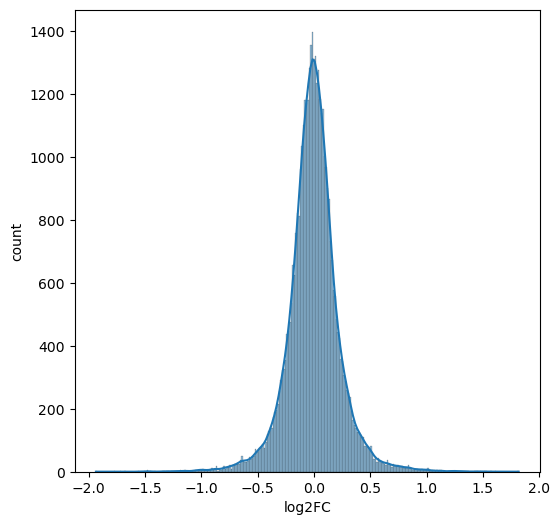

In [12]:
## log2fc distribution of our variants
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=bcMPRAlm_table, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Investigate outliers (high log2FC) and not significant
- expectation: only a few barcodes

In [14]:
# filter for high log2fc and not significant
non_sig_high_log2fc = bcMPRAlm_table[(abs(bcMPRAlm_table["logFC"]) >= 1) & (bcMPRAlm_table["adj.P.Val"] > 0.05)] # 1: 101; 0.5: 1524
len(non_sig_high_log2fc)

101

In [13]:
# number of significant variants
sig_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < 0.05]
print(len(sig_variants)) # 398

low_log2fc = bcMPRAlm_table[abs(bcMPRAlm_table["logFC"]) < 0.5]
print(len(low_log2fc)) # 39468

398
39468


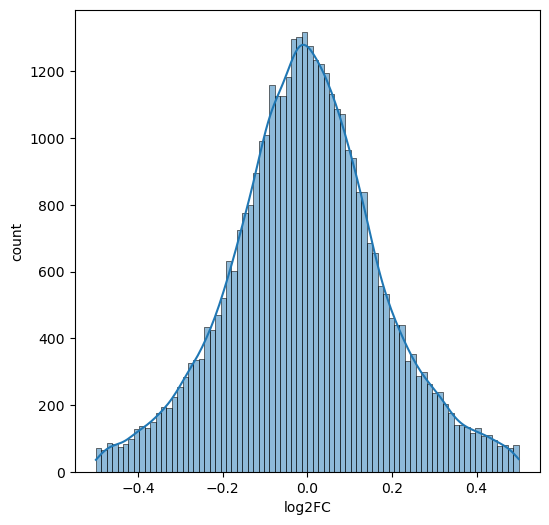

In [24]:
## log2fc distribution
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=low_log2fc, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Connect MPRA results 
- Allel Frequency (AF), Allele Count (AC)
- enformer class (high_effect, low_effect, random) 
- Gene_set (neuro, cardiac, cava, random)

In [56]:
# TODO: add connection between bc_MPRAlm_table and enformer tables
# bcMPRAlm_table
# match one enformer to the bcMPRAlm_table
# define a function for it
# does it for all enformer tables
enformer_cardiac_singleton = pd.read_csv(config["files"]["enformer_cardiac_single"], sep="\t")

In [15]:
bcMPRAlm_table.variant_id.tolist()[:10]

['cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G',
 'cardiac_neuro_cava_random:ANKZF1|ENSG00000163516.14|EH38E2076021|2-219267001-T-C',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T',
 'cardiac_neuro_cava_random:ATR|ENSG00000175054.16|EH38E3544406|3-142578095-C-G',
 'cardiac_neuro_cava_random:CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115774-T-C',
 'cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G',
 'cardiac_neuro_cava_random:SLC1A2|ENSG00000110436.13|EH38E1532674|11-35289966-C-T',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408083-G-T',
 'cardiac_neuro_cava_random:H1-3|ENSG00000124575.7|EH38E3697725|6-26269112-G-T',
 'cardiac_neuro_cava_random:DISC1|ENSG00000162946.23|EH38E2873486|1-231734633-A-G']

In [57]:
enformer_cardiac_singleton.head()

,#CHROM,POS,ID,REF,ALT,DNase_max,INDEX_max,QUAL,FILTER,INFO,gene_set,variant_type,enformer_class
0,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,4254.3410,392_DNASE:CD14-positive,1,PASS,AF=6.57168e-06;AC=1,cardiac,singleton,enformer_high
1,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,4022.5996,"177_DNASE:CD8-positive,",1,PASS,AF=6.56866e-06;AC=1,cardiac,singleton,enformer_high
2,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,3591.8310,392_DNASE:CD14-positive,1,PASS,AF=6.57618e-06;AC=1,cardiac,singleton,enformer_high
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,2754.7705,401_DNASE:common myeloid,1,PASS,AF=6.56763e-06;AC=1,cardiac,singleton,enformer_high
4,chr7,151848098,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,2746.3271,392_DNASE:CD14-positive,1,PASS,AF=6.56978e-06;AC=1,cardiac,singleton,enformer_high


### Positive and Negative numbers
- Overall: 
    - standard: 41284
    - lowConfig: 42137
- Number of significant results
    - standard: 398 
    - lowConfig: 53 
    - TODO: Why do I only find 53 with p-value < 0.05?
- Plot of log2FC distribution
- Plot p-value distribution
- Table of positive and negative log2FC
- Plot of p-value distribution (adjusted p value)

In [3]:
def plot_distribution(df, value_column, n_bins=100, output_path="", title="", x_lable=None, y_lable=None):
    """Plot the distribution of the given column and store the plot in given directory"""
    plt.hist(df[value_column], bins=n_bins)
    if title != "":
        plt.title(title)
    if x_lable:
        plt.xlabel(xlabel=x_lable)
    if y_lable:
        plt.ylabel(ylabel=y_lable)
    if output_path != "":
        plt.savefig(config["plots"]["log2_p_sig_hist"])
    plt.show()
    plt.clf()

398 significant variants


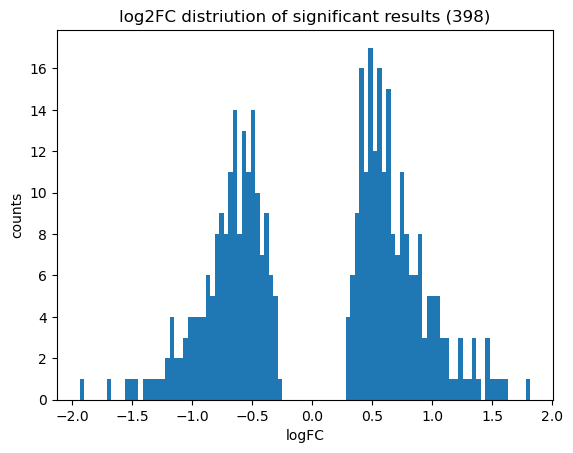

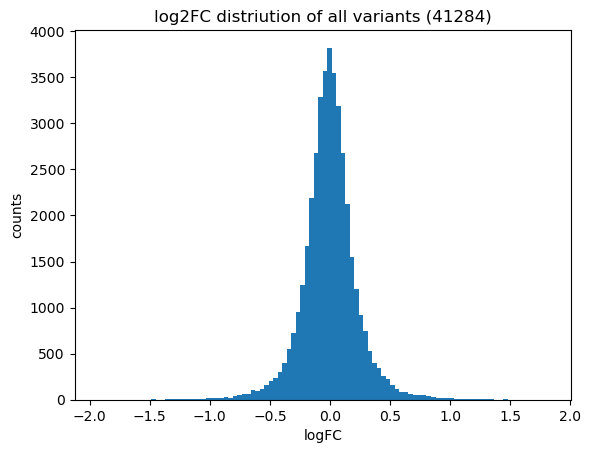

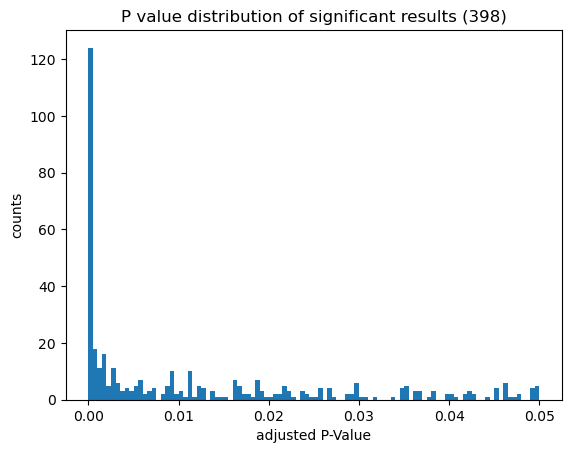

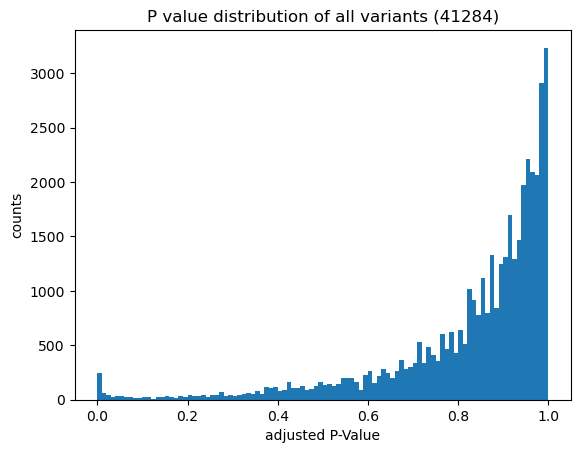

<Figure size 640x480 with 0 Axes>

In [4]:
sig_niveau = 0.05
significant_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < sig_niveau]
print("%s significant variants"%(significant_variants.shape[0]))

# plot log2FC distribution
title = "log2FC distriution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_p_sig_hist"], title=title, x_lable="logFC", y_lable="counts")
title = "log2FC distriution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_all_hist"], title=title, x_lable="logFC", y_lable="counts")

# P value distribution
title = "P value distribution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["sig_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")
title = "P value distribution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["all_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")



### Positive and negative effects
- In all variants
  - Found 20113 (0.487) positive results
  - Found 21171 (0.513) negative results
- Significant (reverse pattern => more positive than negative)
  - Found 214 (0.538) positive results
  - Found 184 (0.462) negative results

In [50]:
# number of positive negative numbers
def split_into_common_rare(df_with_AF_column,  common_threshold=0.05, column="AF"):
    """Splits df into rare and common at threshold"""
    common_vars = df_with_AF_column[df_with_AF_column[column] >= common_threshold]
    rare_vars = df_with_AF_column[df_with_AF_column[column] < common_threshold]
    print(f"Found {len(common_vars)} ({len(common_vars)/len(df_with_AF_column)}) common variants and {len(rare_vars)} ({len(rare_vars)/len(df_with_AF_column)}) rare variants with the common threshold {common_threshold}")
    ultra_rare = df_with_AF_column[df_with_AF_column[column] < 0.01]
    ultra_rare = ultra_rare[ultra_rare["AC"] != 1]
    print(f"Found {len(ultra_rare)} ultra-rare variants")
    print(f"Found {len(df_with_AF_column[df_with_AF_column['AC'] == 1])} singleton variants")
    return common_vars, rare_vars

def split_df_in_pos_neg(df_with_logFC_column, column="logFC", rounding_precision=3):
    """Splits a given data frame based on the logFC into positive and negative values"""
    positive_set = df_with_logFC_column[df_with_logFC_column[column] > 0]
    negative_set = df_with_logFC_column[df_with_logFC_column[column] < 0]
    print(f"Found {len(positive_set)} ({round(len(positive_set)/len(df_with_logFC_column),rounding_precision)}) positive results\nFound {len(negative_set)} ({round(len(negative_set)/len(df_with_logFC_column), rounding_precision)}) negative results")
    return positive_set, negative_set

In [51]:
print("In all variants")
bcMPRAlm_table_positive, bcMPRAlm_table_negative = split_df_in_pos_neg(bcMPRAlm_table)
print("Significant")
sig_positive, sig_negative = split_df_in_pos_neg(significant_variants)

In all variants
Found 20113 (0.487) positive results
Found 21171 (0.513) negative results
Significant
Found 214 (0.538) positive results
Found 184 (0.462) negative results


### Allele frequency (common: AF>1%, rare: AF=<1%, singleton: AC=0)

In [ ]:
# common rare 